In [5]:
import pandas as pd

df = pd.read_csv('../data/spy_features.csv')


Date           0
Close          0
High           0
Low            0
Open           0
Volume         0
RSI            0
MACD           0
MACD_Signal    0
MACD_Hist      0
BB_Upper       0
BB_Middle      0
BB_Lower       0
SMA_20         0
SMA_50         0
SMA_200        0
EMA_12         0
EMA_26         0
ATR            0
OBV            0
Stoch_K        0
Stoch_D        0
Williams_R     0
ROC            0
dtype: int64

In [22]:
##df['Date'] = pd.to_datetime(df['Date'])
##df = df.set_index('Date')
##df.dtypes
##df.index
df.shape

(2939, 24)

In [20]:
df['Label'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.iloc[:-1]
df[['Close', 'Label']].head()

,Close,Label
Date,,
2014-10-16,153.016907,1
2014-10-17,154.824188,1
2014-10-20,156.327454,1
2014-10-21,159.424438,0
2014-10-22,158.290756,1


In [21]:
df['Label'].value_counts()

Label
1    1615
0    1324
Name: count, dtype: int64

55/45 split

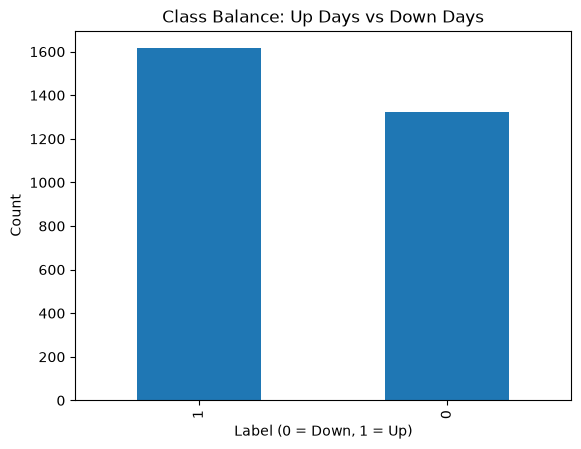

In [23]:
import matplotlib.pyplot as plt

df['Label'].value_counts().plot(kind='bar')
plt.title('Class Balance: Up Days vs Down Days')
plt.xlabel('Label (0 = Down, 1 = Up)')
plt.ylabel('Count')
plt.show()

In [25]:
indicator_cols = df.drop(columns=['Close', 'High', 'Low', 'Open', 'Volume', 'Label'])
indicator_cols.head()

,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,SMA_20,SMA_50,SMA_200,EMA_12,EMA_26,ATR,OBV,Stoch_K,Stoch_D,Williams_R,ROC
Date,,,,,,,,,,,,,,,,,,
2014-10-16,29.535651,-2.301859,-1.390111,-0.911747,166.981727,159.726332,152.470937,159.726332,161.302583,155.350599,156.942693,159.244551,2.364378,330620400,26.556818,19.811762,-73.443182,-5.456300
2014-10-17,36.922371,-2.300348,-1.572159,-0.728189,166.375533,159.224000,152.072467,159.224000,161.275127,155.383728,156.616769,158.917117,2.399692,545245400,39.988027,31.309302,-60.011973,-3.025457
2014-10-20,42.337060,-2.153031,-1.688333,-0.464698,165.822406,158.860493,151.898581,158.860493,161.241597,155.424494,156.572259,158.725290,2.367936,675256400,53.443708,39.996185,-46.556292,-2.098984
2014-10-21,51.562159,-1.766023,-1.703871,-0.062152,165.446869,158.698664,151.950459,158.698664,161.260847,155.482892,157.011056,158.777079,2.427638,830205400,77.487087,56.972941,-22.512913,-1.246727
2014-10-22,48.503148,-1.533122,-1.669721,0.136599,164.722871,158.416483,152.110096,158.416483,161.261839,155.531085,157.207933,158.741055,2.389193,678383400,68.685768,66.538855,-31.314232,-1.834057


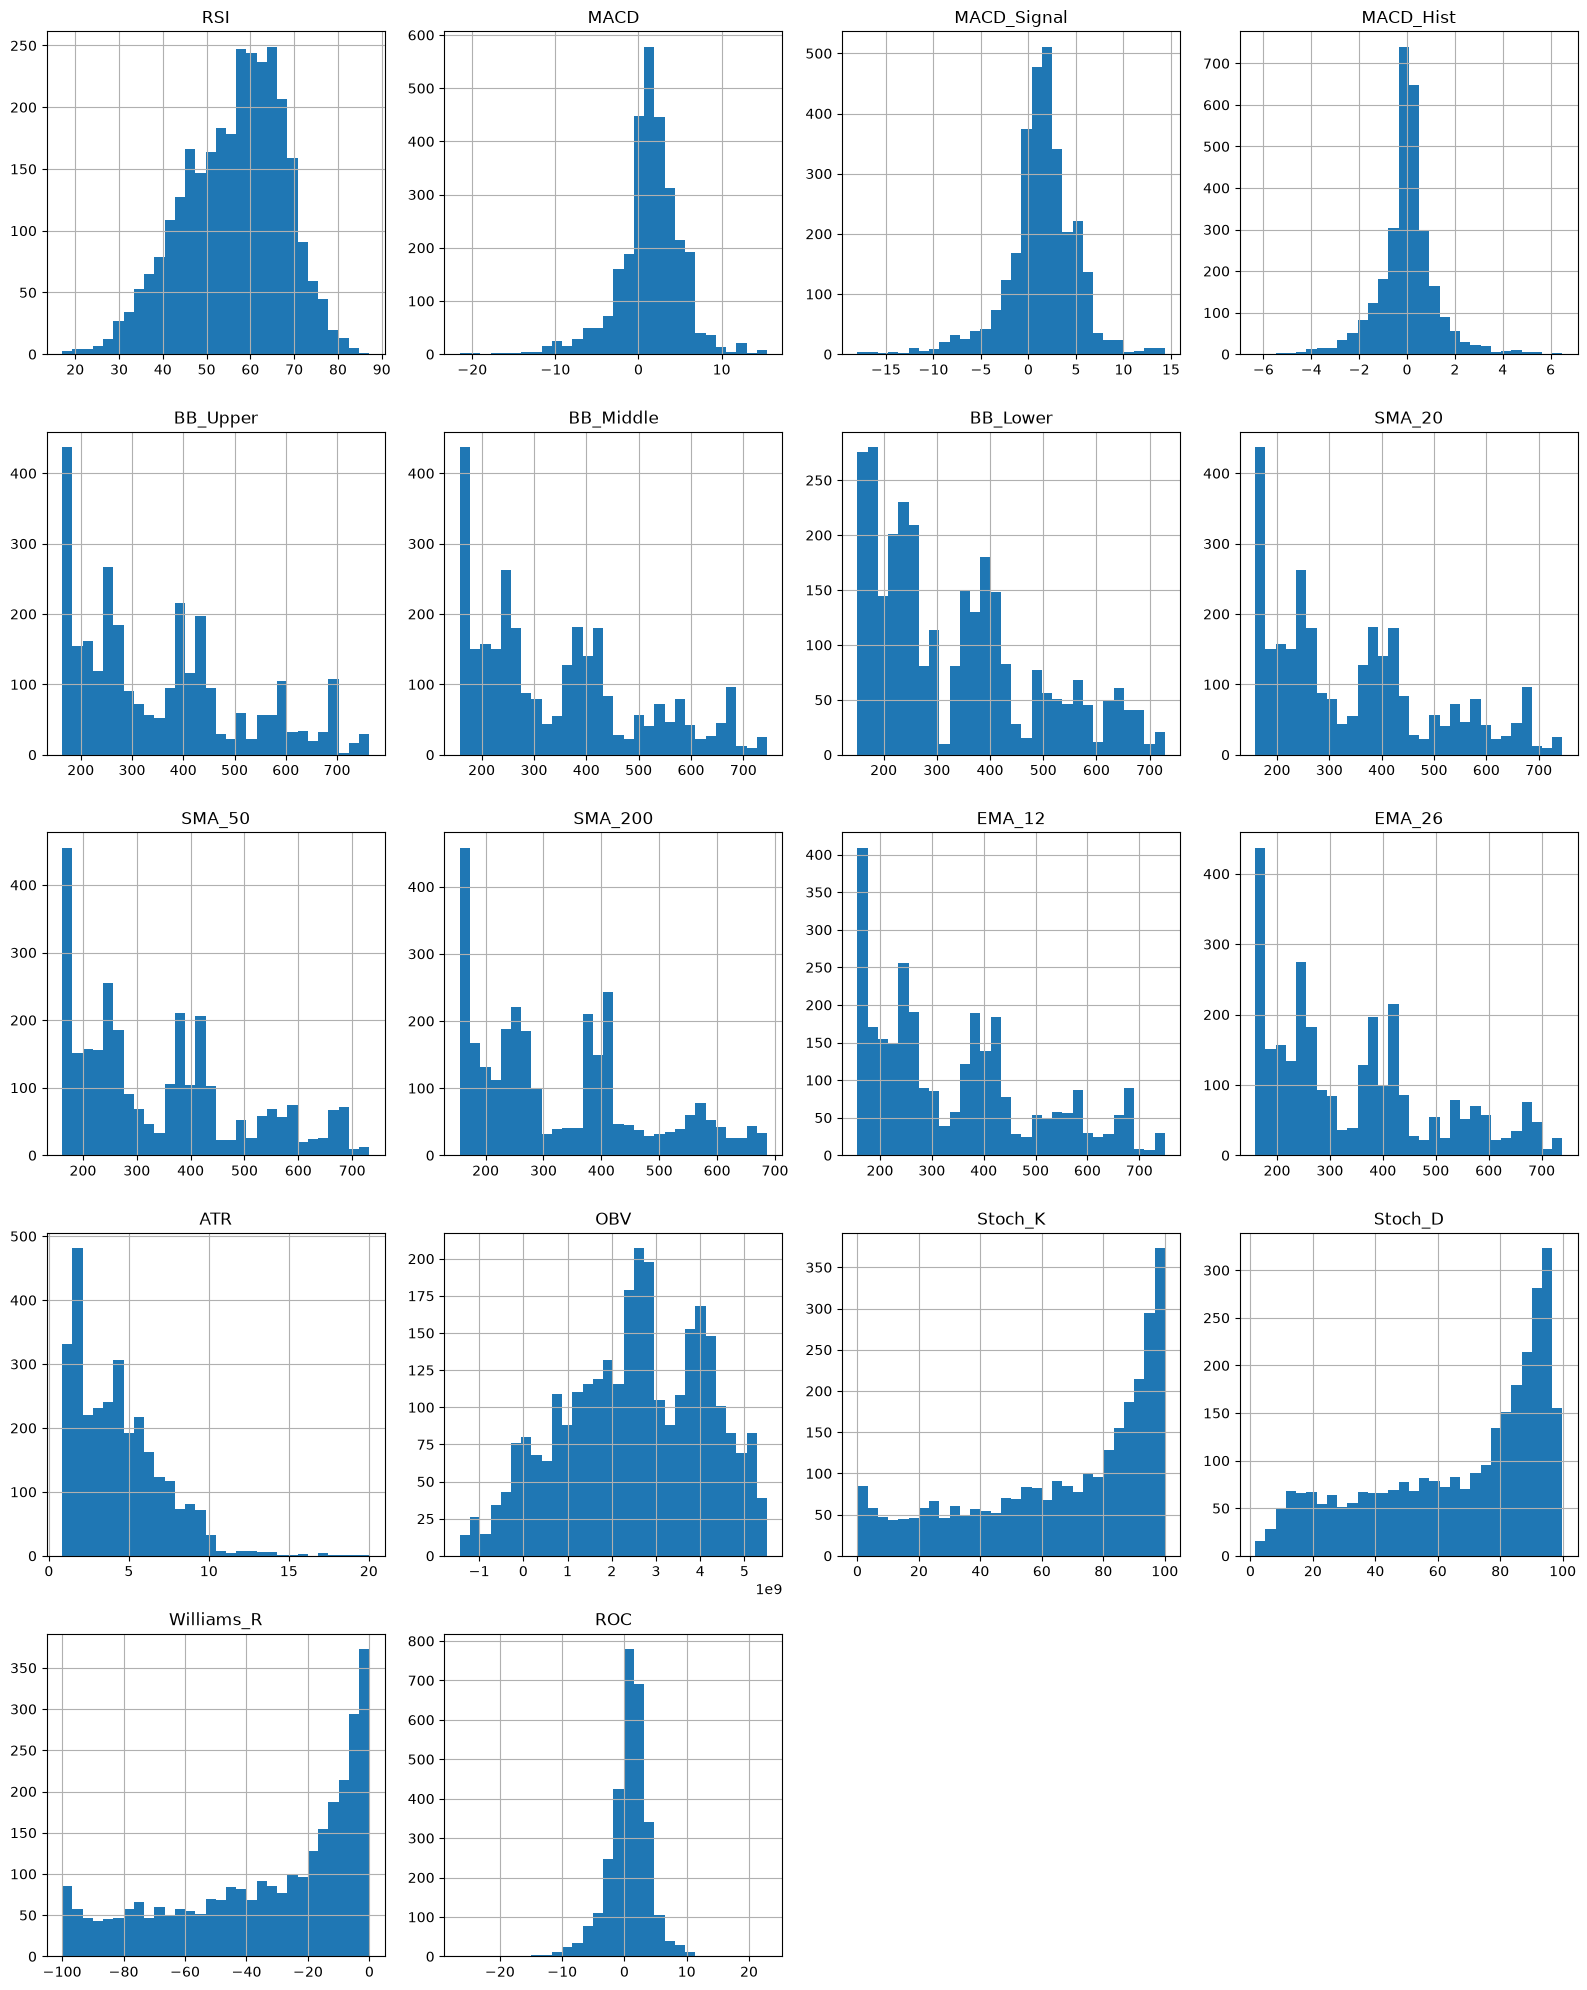

In [26]:
indicator_cols.hist(figsize=(16, 20), bins=30, layout=(5, 4))
plt.tight_layout()
plt.show()

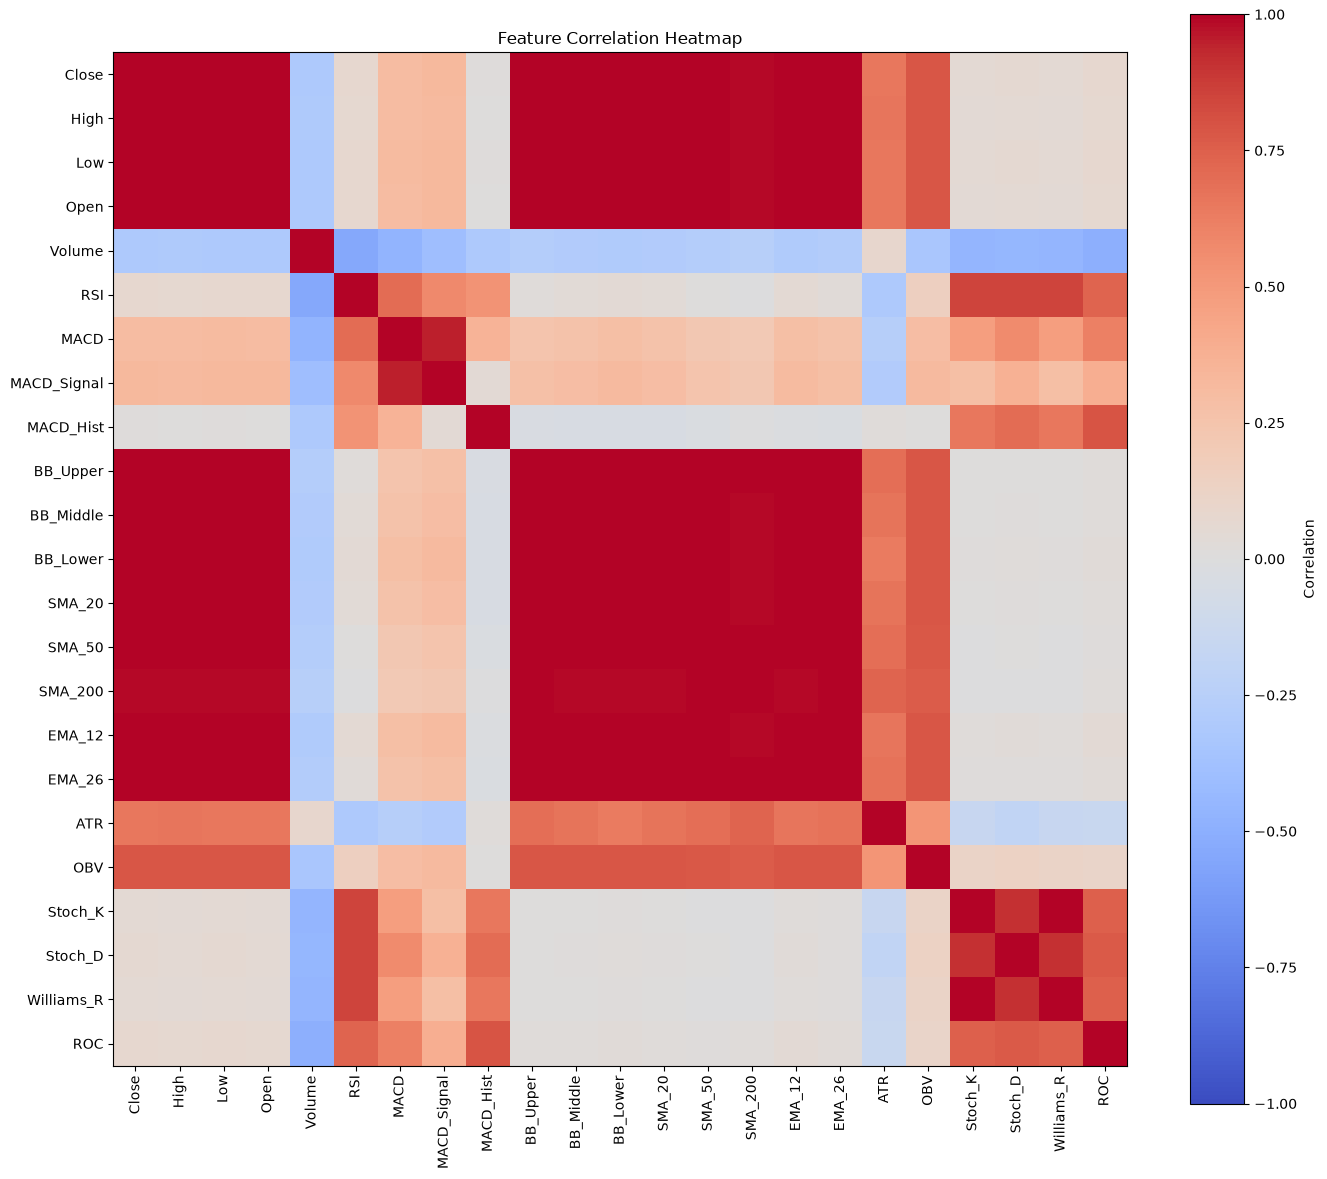

In [27]:
corr_matrix = df.drop(columns=['Label']).corr()

plt.figure(figsize=(14, 12))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

12 of 18 features are highly correlated (>0.9) due to all being price-derived


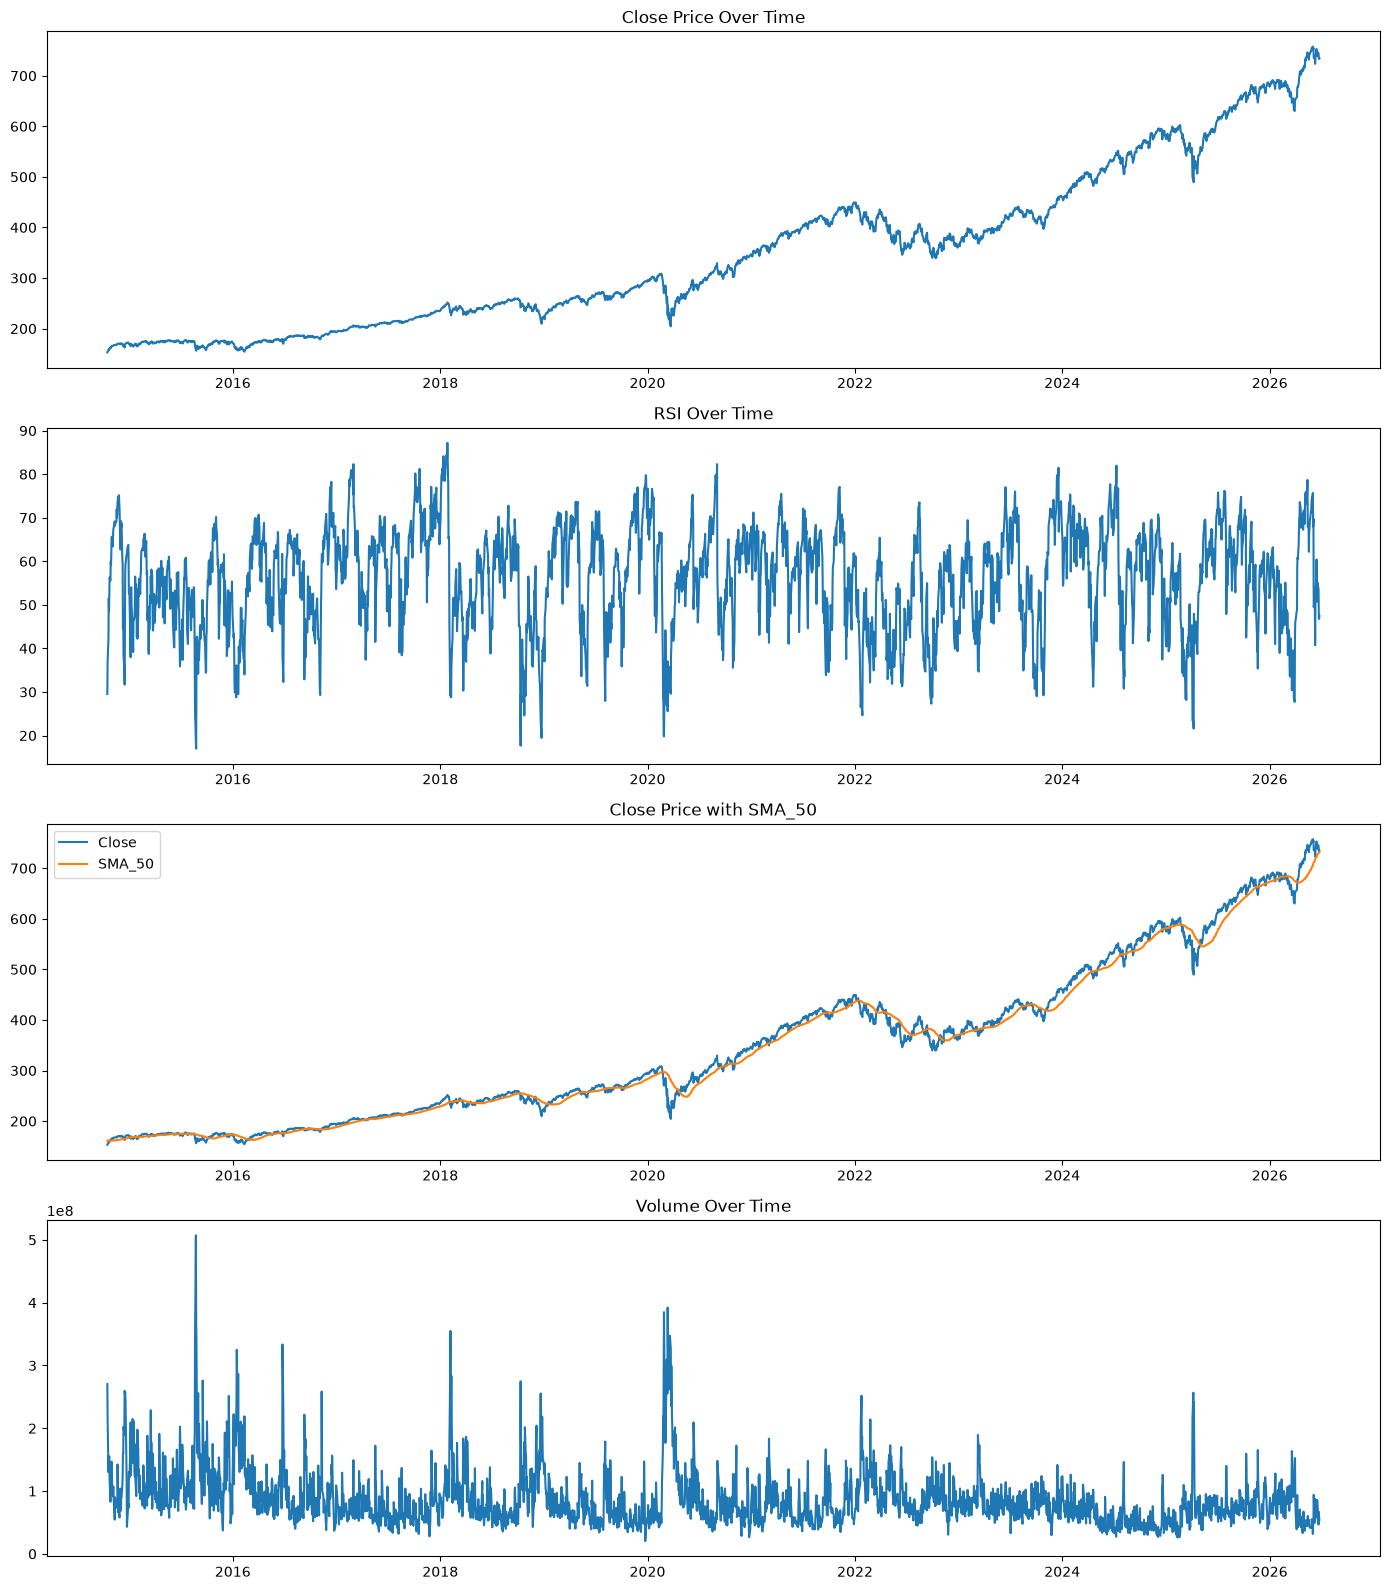

In [28]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

axes[0].plot(df.index, df['Close'])
axes[0].set_title('Close Price Over Time')

axes[1].plot(df.index, df['RSI'])
axes[1].set_title('RSI Over Time')

axes[2].plot(df.index, df['Close'], label='Close')
axes[2].plot(df.index, df['SMA_50'], label='SMA_50')
axes[2].set_title('Close Price with SMA_50')
axes[2].legend()

axes[3].plot(df.index, df['Volume'])
axes[3].set_title('Volume Over Time')

plt.tight_layout()
plt.show()

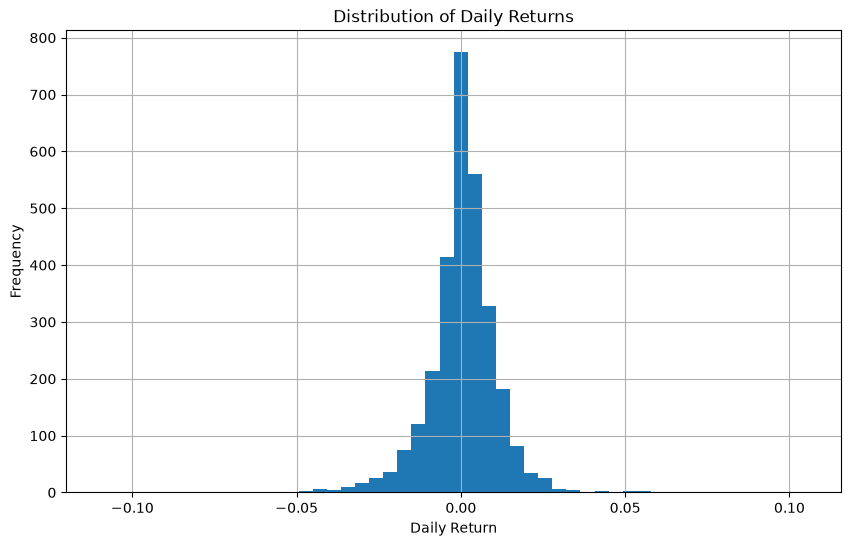

count    2938.000000
mean        0.000595
std         0.011069
min        -0.109424
25%        -0.003663
50%         0.000683
75%         0.005923
max         0.105019
Name: Daily_Return, dtype: float64

In [29]:
df['Daily_Return'] = df['Close'].pct_change()

df['Daily_Return'].hist(bins=50, figsize=(10, 6))
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

df['Daily_Return'].describe()

In [31]:
df['Daily_Return'].idxmin()


Timestamp('2020-03-16 00:00:00')

The worst day was the monday after the pandemic caused nationwide social distancing and quarantine began

In [34]:
df.to_csv('../data/spy_features.csv', index=True)
print(f"Saved {df.shape[0]} rows and {df.shape[1]} columns")
print(df.columns.tolist())


Saved 2939 rows and 25 columns
['Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'ATR', 'OBV', 'Stoch_K', 'Stoch_D', 'Williams_R', 'ROC', 'Label', 'Daily_Return']
